# Results

In [1]:
import pandas as pd

from experiment_config import dataset_path, pfnet_paths
from src.helpers.metrics import build_metrics_table


## Config

In [2]:
DATA_NAME = "DS01"
ARGS_ID = 7

## Load Predictions

In [3]:
ESTIMATION_DIR = dataset_path(DATA_NAME, field="estimation")
_, PRED_DIR = pfnet_paths(ARGS_ID, DATA_NAME)

rep_files = sorted(PRED_DIR.glob("rul_test_r*.csv"))
if not rep_files:
    raise FileNotFoundError(f"No rul_test_r*.csv files found in {PRED_DIR}")
df_preds = pd.concat((pd.read_csv(f) for f in rep_files), ignore_index=True)
n_reps = int(df_preds["rep"].nunique())
print(f"Loaded {len(rep_files)} files spanning {n_reps} repetitions")

FileNotFoundError: No rul_test_r*.csv files found in /lustre/diazgonz/deep-performance-rul/experiments/DS01/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg7/pred_ulevel0.95

## Compute mean prediction

In [ ]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()

In [ ]:
results = pd.DataFrame(columns=["RMSE", "Score", "PICP", "PINAW"])

## Full-life Predictions

In [ ]:
metrics = build_metrics_table(df_preds)
results.loc["full_life"] = [
    metrics["RMSE"],
    metrics["Score"],
    metrics["PICP"],
    metrics["PINAW"],
]

## Benchmark Predictions (RUL<65)

In [ ]:
df_benchmark = df_preds[df_preds["true_rul"] <= 65]
metrics = build_metrics_table(df_benchmark)
results.loc["RUL65"] = [
    metrics["RMSE"],
    metrics["Score"],
    metrics["PICP"],
    metrics["PINAW"],
]

## Degradation Predictions

In [ ]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_test.csv")
test_units = hi_df["unit"].astype(int).unique().tolist()
onsets = {
    unit: hi_df[(hi_df["unit"] == unit) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for unit in test_units
}
df_degpreds = df_preds[df_preds["time"] > df_preds["unit"].map(onsets)]

In [ ]:
metrics = build_metrics_table(df_degpreds)
results.loc["deg"] = [
    metrics["RMSE"],
    metrics["Score"],
    metrics["PICP"],
    metrics["PINAW"],
]

## Combine

In [ ]:
results.index.name = DATA_NAME

results

,RMSE,Score,PICP,PINAW
DS06,,,,
full_life,9.442890,334.836234,0.981366,0.422671
RUL65,9.631685,285.771746,0.977273,0.475102
deg,7.722004,168.659561,0.981651,0.436288


## Save

In [ ]:
results.to_csv(PRED_DIR / "mean_results.csv")

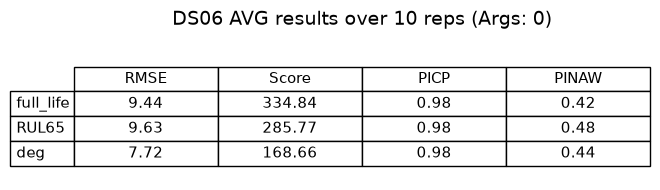

In [ ]:
import matplotlib.pyplot as plt

# Round for presentation
table_df = results.round(2)

fig, ax = plt.subplots(figsize=(7, 2))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)

plt.title(
    f"{DATA_NAME} AVG results over {n_reps} reps (Args: {ARGS_ID})", fontsize=14, pad=20
)
plt.tight_layout()

plt.savefig(PRED_DIR / "mean_results.png", dpi=400)
plt.show()
plt.close()

## Results

## DS01

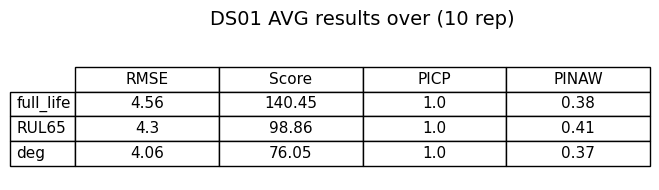

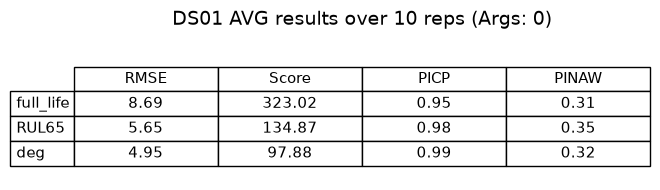
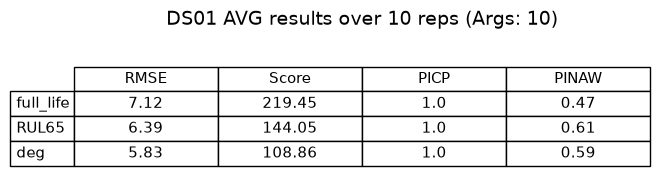

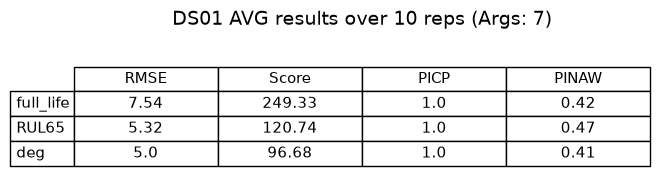

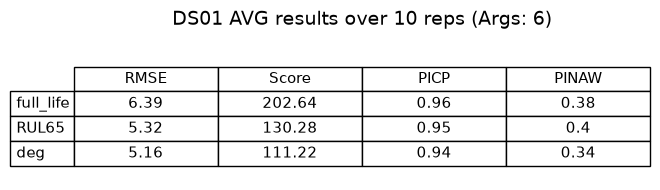

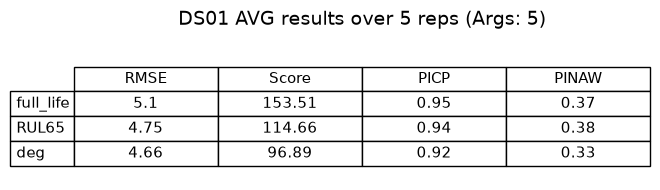

## DS03

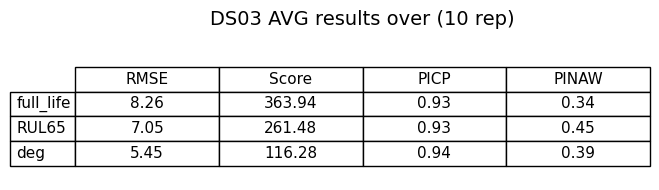

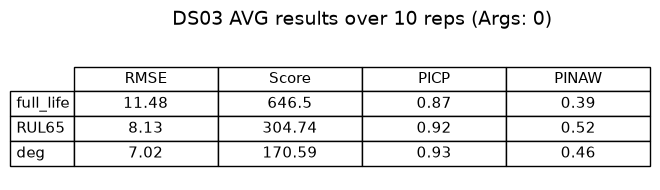

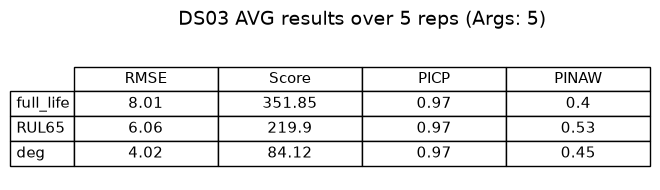

## DS05

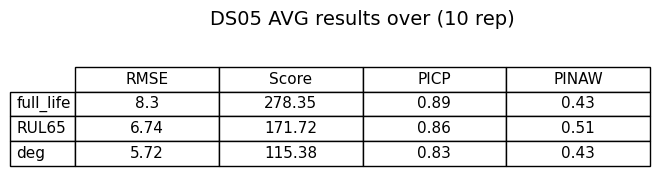

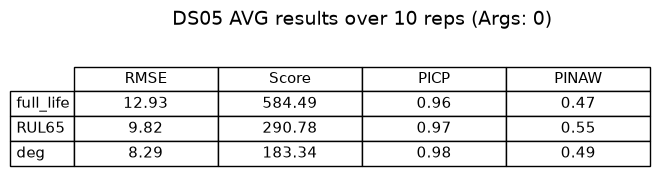

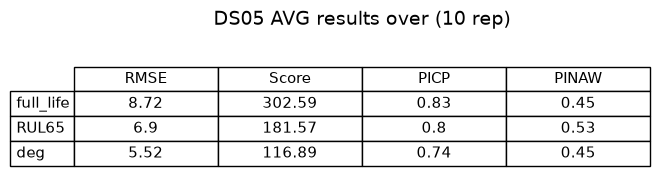

## DS06

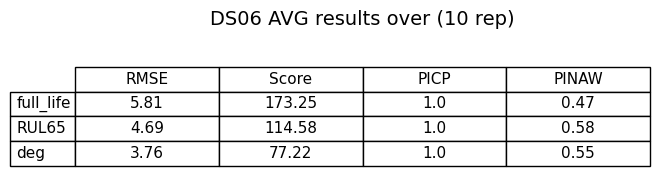

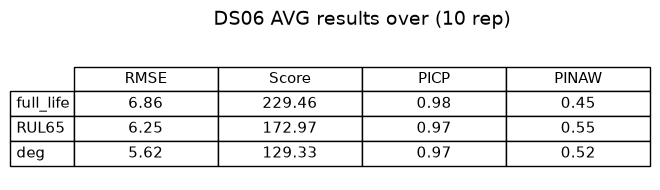

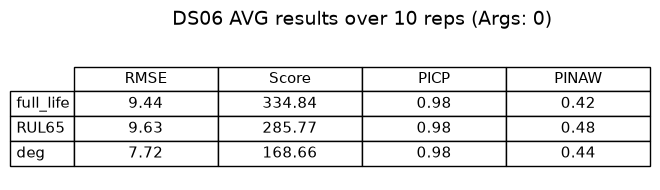